# Task 1 - looking at the data

The dataset has 80 train, 20 val and 12 test images, 256x256 RGB, with a binary mask and
an instance label map for each one. The plotting code is in src/eda.py.


In [1]:
import sys
sys.path.append('..')

from src import eda
from src.data import list_stem
from src.meta_data import load_metadata

meta = load_metadata()
print({s: len(list_stem(s)) for s in ['train', 'val', 'test']})


{'train': 80, 'val': 20, 'test': 12}


## The four density regimes

Images come in four kinds: sparse, normal, dense and clustered. Clustered is the hard one,
because the nuclei touch each other and a threshold cannot separate them.


In [2]:
eda.split_summary()


n_images  objects_mean  objects_min  objects_max
split density                                                    
test  clustered         2          39.5           30           49
      dense             2          76.5           75           78
      normal            6          25.5           19           31
      sparse            2           8.0            8            8
train clustered        13          45.0           34           60
      dense            13          65.2           46           85
      normal           40          26.7           15           39
      sparse           14           8.4            5           12
val   clustered         3          43.0           32           49
      dense             3          69.0           62           81
      normal           10          25.1           17           36
      sparse            4           7.2            5            9

PosixPath('/Users/hoangdat/Data/Herts/Analysis_AI/vision_assignment/outputs/figures/04_density.png')

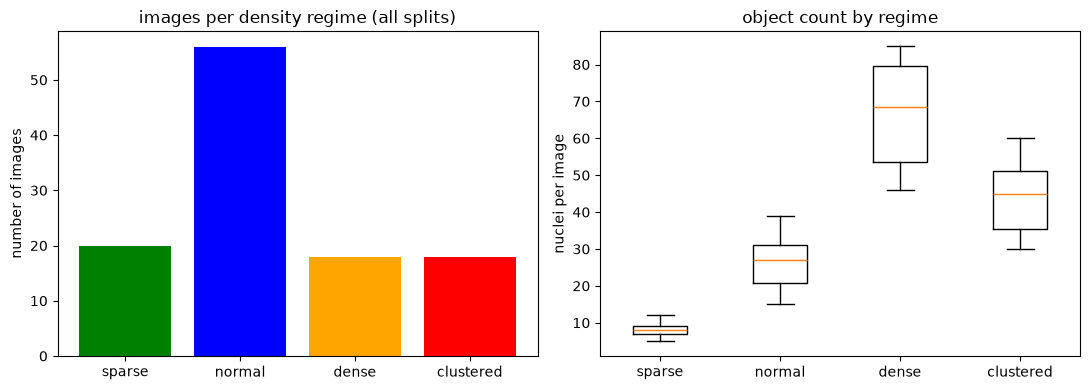

In [3]:
fig = eda.density_plot()
eda.save(fig, '04_density')


## What the images look like


PosixPath('/Users/hoangdat/Data/Herts/Analysis_AI/vision_assignment/outputs/figures/01_sample_grid.png')

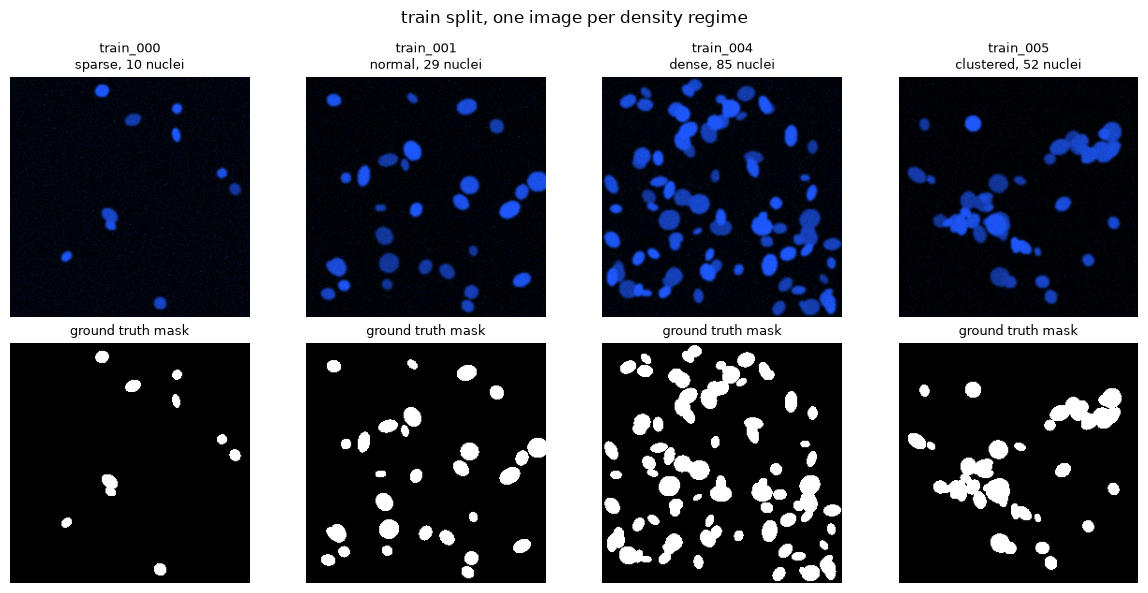

In [4]:
fig = eda.sample_grid('train')
eda.save(fig, '01_sample_grid')


## Intensity

Foreground and background pixels over 20 training images. The two humps hardly overlap,
so a single threshold should work. The y axis is log because 98% of the pixels are background.


PosixPath('/Users/hoangdat/Data/Herts/Analysis_AI/vision_assignment/outputs/figures/02_intensity_hist.png')

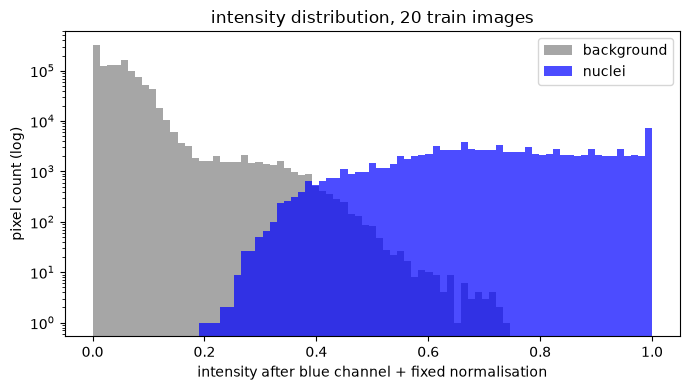

In [5]:
fig = eda.intensity_hist('train', n_images=20)
eda.save(fig, '02_intensity_hist')


## Which channel

The stain is DAPI-like so the signal is in the blue channel. The number on each panel is
the mean intensity gap between nuclei and background, on a 0 to 255 scale.


{'blue': 175.8, 'luminance': 61.2, 'max': 175.8}


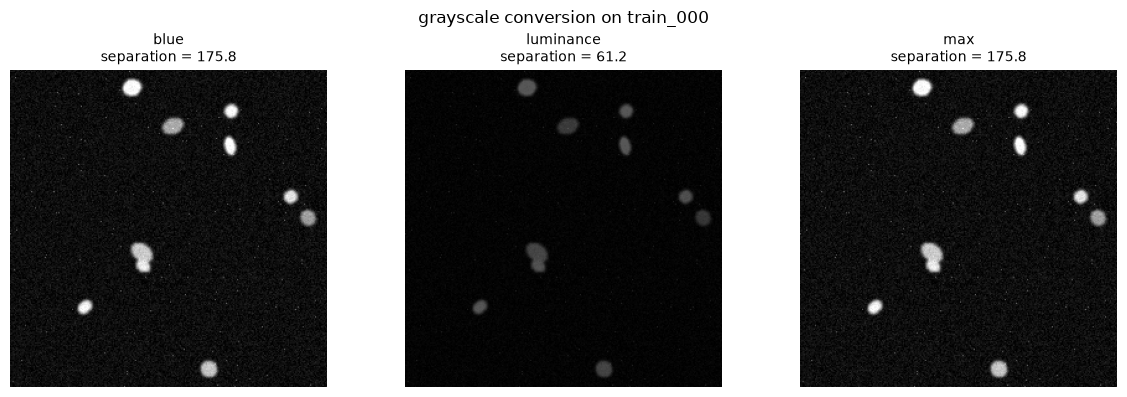

In [6]:
fig, gaps = eda.channel_compare('train_000')
eda.save(fig, '03_channel_compare')
print({k: round(float(v), 1) for k, v in gaps.items()})


## A problem with the ground truth

metadata.csv says how many nuclei the generator placed. But the generator draws them one
over another, so a nucleus that ends up fully covered still has a row in metadata while no
pixel of it is left in the image.

This matters for counting. On those images no method can reach the metadata number, so I
count the label maps instead. Density and the intensity statistics still come from metadata.


In [7]:
audit = eda.gt_audit()
print(f"images losing nuclei: {(audit['lost'] > 0).sum()} / {len(audit)}")
audit.groupby('density')['lost'].agg(['mean', 'max']).round(2)


images losing nuclei: 23 / 112


,mean,max
density,,
clustered,2.00,6
dense,0.44,2
normal,0.07,1
sparse,0.00,0


In [8]:
audit[audit['lost'] > 0].sort_values('lost', ascending=False).head(10)


,image_id,split,density,placed,visible,lost
105,test_005,test,clustered,49,43,6
47,train_047,train,clustered,53,47,6
35,train_035,train,clustered,52,48,4
65,train_065,train,clustered,60,56,4
17,train_017,train,clustered,42,38,4
23,train_023,train,clustered,53,50,3
53,train_053,train,clustered,37,35,2
96,val_016,val,dense,62,60,2
71,train_071,train,clustered,34,32,2
59,train_059,train,clustered,45,43,2


PosixPath('/Users/hoangdat/Data/Herts/Analysis_AI/vision_assignment/outputs/figures/05_gt_audit.png')

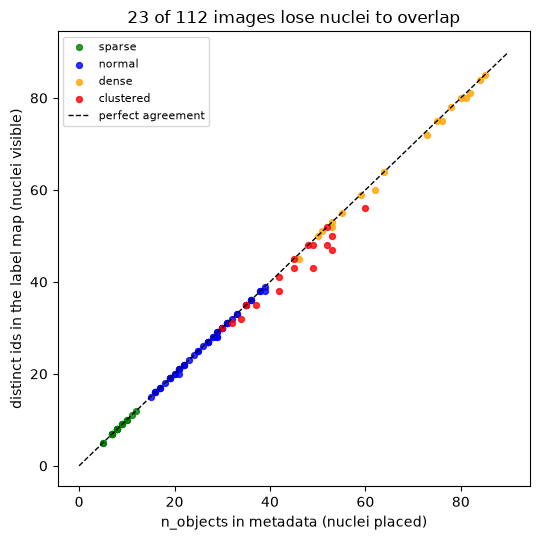

In [9]:
fig = eda.gt_audit_plot(audit)
eda.save(fig, '05_gt_audit')


## The corrupted images

Four extra test images, blurred and with the contrast crushed. They have no masks, so they
are scored against the mask of the clean image they came from.


PosixPath('/Users/hoangdat/Data/Herts/Analysis_AI/vision_assignment/outputs/figures/06_corrupted.png')

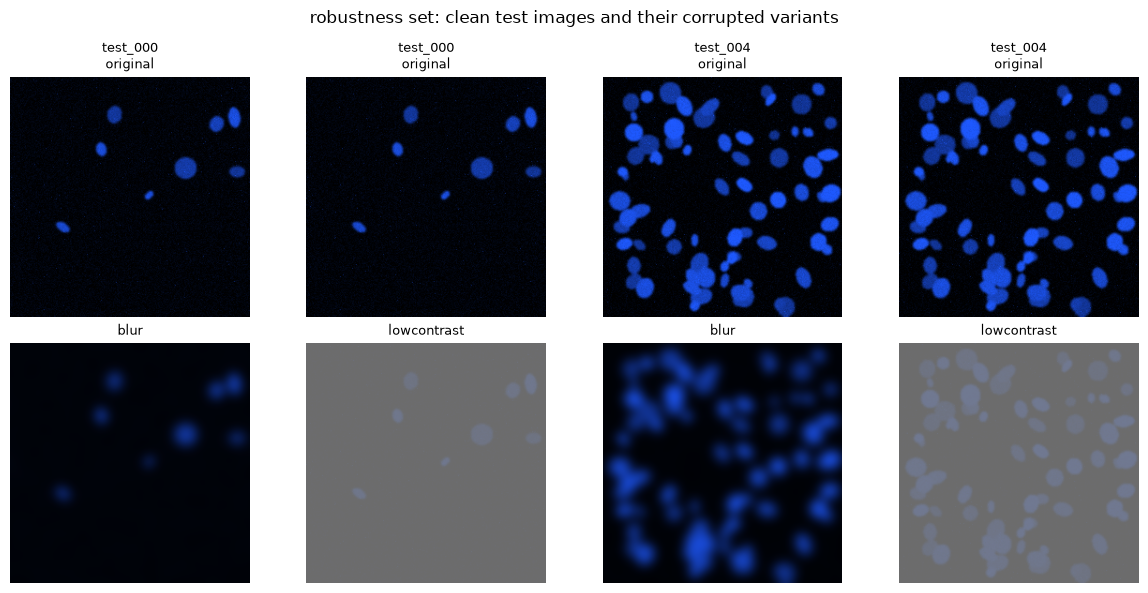

In [10]:
fig = eda.corrupted_preview()
eda.save(fig, '06_corrupted')
